# 04 · Hazır YOLO modeli
Aşama 5: İnternetten hazır, eğitilmiş bir YOLO modelini kendi termal fotoğraflarımızda deniyoruz.

## 1. Hazırlık: hazır modeli yükle
`yolo11n.pt` internetten indirilmiş, **COCO** veri setiyle eğitilmiş bir model. COCO: günlük hayattan toplanmış milyonlarca **normal renkli** fotoğraf, 80 sınıf (insan, araba, şişe, telefon...).
Bizim 7 sınıfımızdan (drone, mine, gun...) haberi yok.

In [5]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("../models/yolo11n.pt")

siniflar = model.names              # tanıdık isim: numara → sınıf adı sözlüğü

print(len(siniflar))

80


## 2. Deneme 1: kuşbakışı termal otopark
Bu fotoğrafta etiketlere göre **21 nesne** var (20 car + 1 other_vehicle).
`model(...)` fotoğrafı modele verir, `sonuc.boxes` bulunan kutuları tutar. Her kutuda sınıf numarası (`kutu.cls`) ve güven skoru (`kutu.conf`) vardır.

**Sonuç: 4 kutu — cell phone ve bottle.** 17 nesne kaçırıldı, bulunanların sınıfı da yanlış.

In [8]:
ad = "02_hituav__0_100_50_0_08164__c5427da128"
bolum = "train"

sonuc = model("../data/kucuk_paket/images/" + bolum + "/" + ad + ".png", verbose=False)[0]

print(len(sonuc.boxes))

4


### Tahminleri resmin üstünde göster
`sonuc.plot()` kutuları, sınıf adlarını ve güven skorlarını çizip **BGR** görüntü verir; göstermeden önce RGB'ye çevrilir.

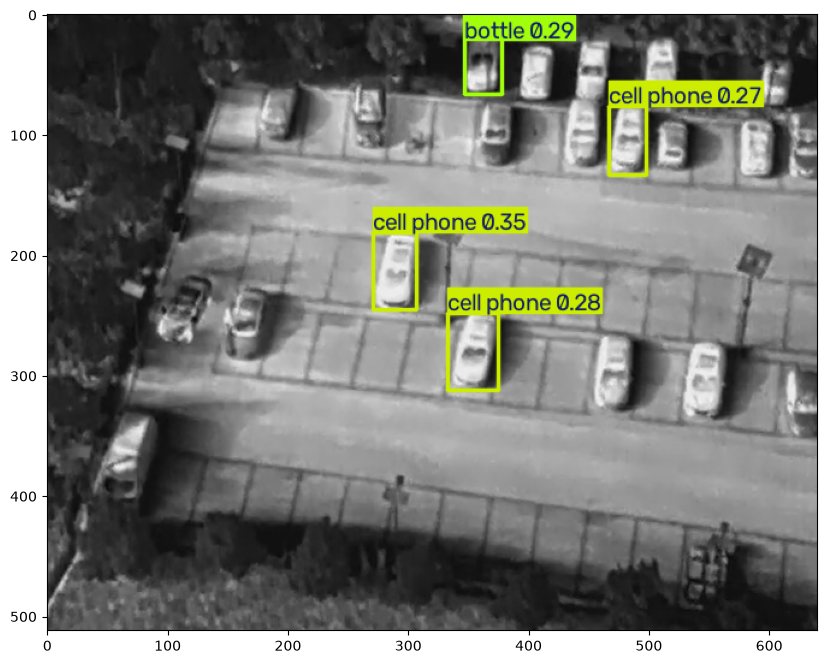

In [9]:
cizim = sonuc.plot()

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()

## 3. Deneme 2: sokak seviyesinden termal görüntü
Aynı model, yine termal bir fotoğraf. Gerçekte 3 araba + 5 insan var.

**Sonuç: 5 kutu — car (0.93, 0.91, 0.77) ve person (0.42, 0.36).** Bu sefer büyük ölçüde doğru.

5
car 0.9264606237411499
car 0.9129897356033325
car 0.7709596753120422
person 0.4244730472564697
person 0.3647904396057129


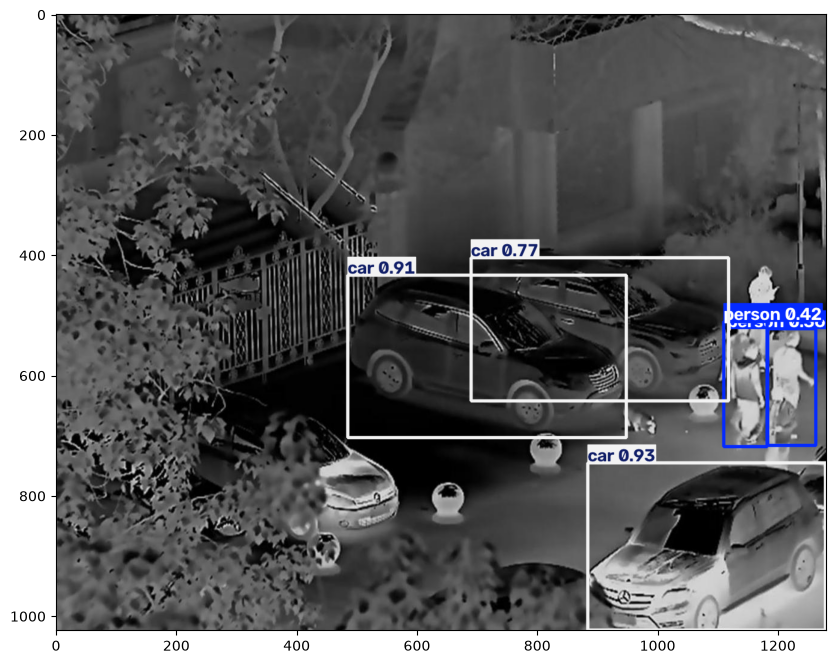

In [10]:
ad = "03_llvip__120019__91781a1c2d"
bolum = "train"

sonuc = model("../data/kucuk_paket/images/" + bolum + "/" + ad + ".png", verbose=False)[0]

print(len(sonuc.boxes))

for kutu in sonuc.boxes:
    numara = int(kutu.cls)
    guven = float(kutu.conf)
    print(model.names[numara], guven)

cizim = sonuc.plot()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()

## Aşama 5'in sonucu: alan farkı (domain gap)

| | Otopark (kuşbakışı) | Sokak (yandan) |
|---|---|---|
| Ne dedi? | cell phone, bottle | car, person |
| Güven | 0.27–0.35 | 0.36–0.93 |
| Doğru mu? | ❌ | ✅ |

Model COCO'da arabaları hep **yandan/önden** görmüş. Tepeden bakınca araba yalnızca parlak bir dikdörtgen: modelin bildiği şeylere benzemiyor, en yakın tahmini "cep telefonu" oluyor. Üstelik kuşbakışı fotoğraflarda nesneler çok küçük.

Modelin eğitildiği veri ile kullanıldığı verinin birbirine benzememesine **alan farkı (domain gap)** denir.

**Bu yüzden Aşama 6'da kendi modelimizi eğiteceğiz:** hazır model hem kuşbakışı termal görüntülerde çalışmıyor, hem de drone / mine / gun gibi sınıfları hiç tanımıyor.